**Uczenie Głębokie (laboratorium)**

Dominik Filipiak

`df[🏒]amu.edu.pl`

Materiały zawierają wybrane fragmenty materiałów pomocniczych, które przygotowałem na potrzeby kursu Deep Learning dla studentów kierunku Machine Learning na Wydziale Matematyki, Informatyki i Mechaniki UW.

Cześć kodu bazuje na [notebookach z kursu Deep Learning](https://github.com/mim-ml-teaching/public-dnn-2024-25/blob/main/docs/DNN-Lab-4-MNIST-in-Pytorch-student-version.ipynb) dla studentów kierunku Machine Learning na Wydziale Matematyki, Informatyki i Mechaniki UW.

## Proste sieci neuronowe

1. Wielowarstwowy peceptron.
2. Funkcje aktywacji.
3. Inicjalizacja wag.


In [21]:
import matplotlib
import matplotlib.pyplot as plt
from datetime import datetime
from functools import partial
from pathlib import Path
from typing import Optional
from tqdm import tqdm
from typing import Literal, Optional


import torch
import torch.nn as nn               # w uproszczeniu zawiera klasy stanowych obiektów (np. wartsw przechowujących gradient)
import torch.nn.functional as F     # w uproszczeniu bezstanowe operacje (np. relu, softmax)
import torch.optim as optim
from torch.utils.data import Subset
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms


matplotlib.style.use('dark_background')


### Wyświetlanie danych

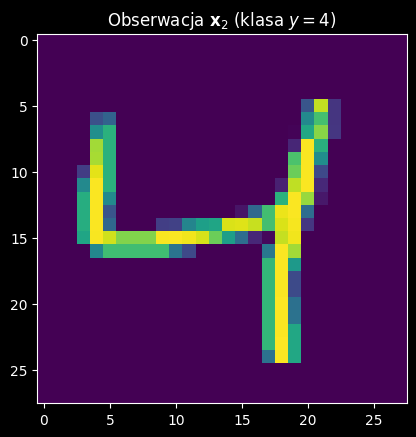

In [22]:
def plot_mnist(index: int, train: bool = True):
    """Wyświetla obserwację o numerze `index` ze podzbioru `train` lub `test` zbioru MNIST.

    Args:
        index (int): Numer obrazka do wyświetlenia.
    """
    mnist = datasets.MNIST('../data', train=train, download=True)
    plt.imshow(mnist.data[index])
    plt.title("Obserwacja $\mathbf{x}_{" + str(index) + "}$ " + f"(klasa $ y={mnist.targets[index]}$)")
    plt.show()

plot_mnist(index=2)


### Wczytywanie danych

Transformacje pozwalają na rozmaite przekształcenia danych wejściowych.
Ten zestaw funkcji będzie zaaplikowany na kazdej obserwacji.

Zacznijmy od najprostszych - przekształcenie obrazka (`PIL.Image`) na tensor oraz jego normalizację.

Tu mamy 60.000 obrazków w rozmiarze $28 \times 28$ oraz ich klas w zbiorze uczącym oraz 10.000 w zbiorze testowym.

In [23]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_val_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('../data', train=False, transform=transform)

print(
    f"train_val_data:\t{len(train_val_dataset)}\n"
    f"test_data:\t{len(test_dataset)}\n"
    )

train_val_data:	60000
test_data:	10000



Musimy sami sobie to podzielić sobie train i val.

In [24]:
train_dataset = Subset(train_val_dataset, indices=range(0, 55_000))
val_dataset = Subset(train_val_dataset, indices=range(55_000, 60_000))

print(
    f"train_data:\t{len(train_dataset)}\n"
    f"val_data:\t{len(val_dataset)}\n"
    f"test_data:\t{len(test_dataset)}\n"
    )

train_data:	55000
val_data:	5000
test_data:	10000



### Perceptron

Jednowarstwowy perceptron realizuje klasyczną operację liniową:
$$
\mathbf{W} \mathbf{x} + \mathbf{b}
$$

Gdzie:
- $\mathbf{W}$ – macierz wag (u nas o wymiarach $ 10 \times 784 $),
- $\mathbf{x}$ – wejściowy wektor cech (o wymiarach $ 784 $),
- $\mathbf{b}$ – wektor biasu (o wymiarach $ 10 $).

W klasycznym perceptronie nie stosujemy funkcji aktywacji (np. ReLU), więc przekształcenie pozostaje liniowe.

Na wyjściu stosujemy funkcję softmax:
$$
\mathbf{\hat{y}}_i = \frac{e^{\mathbf{x}_i}}{\sum_{j} e^{\mathbf{x}_j}}
$$
co pozwala interpretować wartości jako prawdopodobieństwa klas (których w tym wypadku jest 10).

Struktura modelu:
- **Wejście**: "spłaszczone" dane o wymiarze $ 784 $.
- **Warstwa wyjściowa**: 10 neuronów, odpowiadających klasom.
- **Brak warstw ukrytych** – klasyczny perceptron.



In [25]:
class Perceptron(nn.Module):
    def __init__(self, input_size=784, output_size=10):
        super(Perceptron, self).__init__()
        self.layer = nn.Linear(input_size, output_size)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)   # Spłaszczamy wejście
        x = self.layer(x)                   # Operacja liniowa Wx + b
        output = F.softmax(x, dim=1)        # softmax dla klasyfikacji
        return output


### Wielowarstwowy perceptron
...czyli prosta sieć neuronowa.

Rozważamy sieć neuronową składającą się z warstw w pełni połączonych, której zadaniem jest klasyfikacja danych wejściowych.
Każda warstwa wykonuje następujące operacje matematyczne:

Dane wejściowe $\mathbf{X}$ (np. obraz $28 \times 28$ pikseli) są spłaszczane do wektora $\mathbf{x} \in \mathbb{R}^{784}$.

Dla każdej warstwy $ l $ transformacja danych odbywa się według wzoru:
$$
\mathbf{x}^{(l+1)} = f(\mathbf{W}^{(l)} \mathbf{x}^{(l)} + \mathbf{b}^{(l)})
$$

Gdzie:
- $ \mathbf{x}^{(l)} $ - wejście do warstwy $ l $,
- $ \mathbf{W}^{(l)} \in \mathbb{R}^{n_{l+1} \times n_l} $ - macierz wag,
- $ \mathbf{b}^{(l)} \in \mathbb{R}^{n_{l+1}} $ - wektor biasu,
- $ f(z) = \text{ReLU}(z) = \max(0, z)$ - funkcja aktywacji (tu ReLU - inne przykłady to `sigmoid` lub `tanh`).

Ostatnia warstwa oblicza wynik:
$$
\mathbf{x}^{(L)} = \mathbf{W}^{(L-1)} \mathbf{x}^{(L-1)} + \mathbf{b}^{(L-1)}
$$

Na końcu stosujemy funkcję softmax dla klasyfikacji:
$$
\mathbf{y}_i = \frac{e^{\mathbf{x}_i}}{\sum_{j} e^{\mathbf{x}_j}}
$$



In [26]:
class MultilayerPerceptron(nn.Module):
    def __init__(self):
        super(MultilayerPerceptron, self).__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.softmax(x, dim=1)

A gdyby tak dynamicznie określić jak wygląda nasza sieć?

In [27]:
class MultilayerPerceptron(nn.Module):
    def __init__(self, layers: list[int]=[784, 128, 128, 10], activation = F.relu):
        super(MultilayerPerceptron, self).__init__()
        self.layers = nn.ModuleList([nn.Linear(a, b) for a, b in zip(layers[:-1], layers[1:])])
        self.activation = activation

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.flatten(x, start_dim=1) # "spłaszczamy" wejście z (batch_size x 28 x 28) na (batch_size x 784)
        for l in self.layers[:-1]:
          x = l(x)
          x = self.activation(x)
        x = self.layers[-1](x)
        output = F.softmax(x, dim=1)
        return output

### Trening

In [28]:
def train_epoch(
        model: torch.nn.Module,
        device: torch.device,
        train_loader: torch.utils.data.DataLoader,
        optimizer: torch.optim.Optimizer,
        epoch: int,
        writer: Optional[SummaryWriter] = None,
        ):
    """Epoka treningu.

    Args:
        model (torch.nn.Module): Model który trenujemy.
        device (torch.device): Urządzenie na którym trenujemy.
        train_loader (torch.utils.data.DataLoader): `DataLoader` z danymi do trenowania.
        optimizer (torch.optim.Optimizer): Algorytm optymalizacji.
        epoch (int): Nr epoki (na potrzeby logowania)
        writer (SummaryWriter, optional): Opcjonalny obiekt do logów tensorboard.
    """

    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)       # przenosimy dane na urządzenie (np. CPU, GPU, MPS...)
        optimizer.zero_grad()                                   # zerujemy gradient
        output = model(data)                                    # feed-forward
        loss = F.cross_entropy(output, target)                  # obliczenie aktualnego kosztu
        loss.backward()                                         # liczmy gradienty propagacją wsteczną
        optimizer.step()                                        # aktaulizacja wag (np. krok w SGD)

    if writer:
        writer.add_scalar("train/loss", loss.detach().cpu().item(), epoch)

In [29]:
def _val_or_test_epoch(
        model: torch.nn.Module,
        device: torch.device,
        test_loader: torch.utils.data.DataLoader,
        val_or_test: Literal["val", "test"],
        epoch: Optional[int] = None,
        writer: Optional[SummaryWriter] = None
        ):
    """Epoka ewaluacji (walidacja lub test).

    Args:
        model (torch.nn.Module): Model który trenujemy.
        device (torch.device): Urządzenie na którym trenujemy.
        test_loader (torch.utils.data.DataLoader): `DataLoader` z danymi do ewaluacji.
        val_or_test (Literal): `"val"` dla walidacji, `"test"` dla testu.
        epoch (int, optional): Nr epoki (na potrzeby logowania)
        writer (SummaryWriter, optional): Opcjonalny obiekt do logów tensorboard.
    """
    
    model.eval()    # ustawiamy model w tryb ewaluacji
    test_loss = 0
    correct = 0
    with torch.no_grad():   # nie liczymy gradientów
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)               # indeks najbardziej prawdopodobnej kategorii
            correct += pred.eq(target.view_as(pred)).sum().item()   # liczba poprawnych predykcji

        test_loss /= len(test_loader.dataset)
        accuracy = 100. * correct / len(test_loader.dataset)

        if writer:
            writer.add_scalar(f"{val_or_test}/loss", test_loss, epoch)
            writer.add_scalar(f"{val_or_test}/accuracy", accuracy, epoch)

        return test_loss

val_epoch = partial(_val_or_test_epoch, val_or_test="val")
test_epoch = partial(_val_or_test_epoch, val_or_test="test")

Ustalmy hiperparametry oraz zmienne pomocnicze.

In [30]:
def get_torch_device() -> torch.device:
    """Funkcja pomocnicza do określenia na którym urządzeniu będziemy wykonywać obliczenia."""
    if torch.cuda.is_available():
        return torch.device("cuda") # NVIDIA GPU
    elif torch.backends.mps.is_available():
        return torch.device("mps")  # Apple Silicon - uwaga, nie wszysko działa. W razie kłopotów przejdź na CPU.
    else:
        return torch.device("cpu")  # CPU

In [31]:
seed = 1
device = get_torch_device()

batch_size = 256
test_batch_size = 1000
epochs = 5
learning_rate = 1e-2
layers = [784, 64, 64, 10]

In [32]:
torch.manual_seed(seed)

train_kwargs = {'batch_size': batch_size}
test_kwargs = {'batch_size': test_batch_size}

if torch.cuda.is_available():
    cuda_kwargs = {'num_workers': 1,
                    'pin_memory': True,
                    'shuffle': True}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

Do ładowania automatycznego danych w batchach przyda się `DataLoader`.

In [33]:
train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs)
val_loader = torch.utils.data.DataLoader(val_dataset, **test_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

Nie pozostaje nam nic innego niz nauka.

In [34]:
run_name = f"mlp_adam_{'-'.join(map(str, layers))}_lr{learning_rate}_{str(datetime.now().timestamp())}"

model = MultilayerPerceptron(layers=layers).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

with SummaryWriter(Path("runs") / run_name) as writer:
    for epoch in tqdm(range(0, epochs), desc=run_name):
        train_epoch(model, device, train_loader, optimizer, epoch, writer)
        val_epoch(model, device, test_loader, epoch=epoch, writer=writer)
    test_epoch(model, device, test_loader, epoch=epoch, writer=writer)

mlp_adam_784-64-64-10_lr0.01_1743356067.647658: 100%|██████████| 5/5 [04:33<00:00, 54.70s/it]


Przetestujmy teraz wytrenowany model.

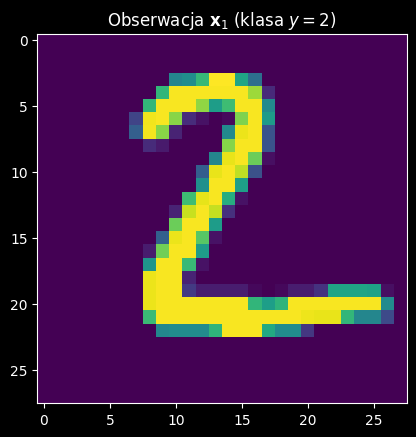

Model zwrócił tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>),
czyli nasza predykcja wynosi y_hat=2


In [35]:
image_index = 1


mnist_test = datasets.MNIST('../data', train=False, download=False, transform=transform)
test_input = mnist_test.data[image_index:image_index+1].float().to(device)
test_output = model(test_input)

plot_mnist(image_index, train=False)
print(f"Model zwrócił {test_output},\nczyli nasza predykcja wynosi y_hat={test_output.argmax(dim=1).item()}")

# Zadania do samodzielnego rozwiązania

## Z1. Najlepszy model
Model po ostatniej epoce niekoniecznie jest najlepszym modelem.

Przygotuj taką pętlę treningową, która będzie przechowywała najlepszy model na podstawie walidacji i uzyje go do testowania.

In [36]:
import copy

def train_loop(model, optimizer, device, train_loader, test_loader, epochs, run_name):
    best_val_loss = float('inf')
    best_model_state = None
    with SummaryWriter(Path("runs") / run_name) as writer:
        for epoch in tqdm(range(0, epochs), desc=run_name):
            train_epoch(model, device, train_loader, optimizer, epoch, writer)
            val_loss = val_epoch(model, device, test_loader, epoch=epoch, writer=writer)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                print(f"Epoch {epoch}: New best model with loss {best_val_loss:.4f}")

        model.load_state_dict(best_model_state)
        return test_epoch(model, device, test_loader, epoch=epoch, writer=writer)

In [48]:
run_name = f"mlp_adam_{'-'.join(map(str, layers))}_lr{learning_rate}_{str(datetime.now().timestamp())}"

model = MultilayerPerceptron(layers=layers).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

best_loss = train_loop(model, optimizer, device, train_loader, test_loader, epochs, run_name)
print(f"best loss = {best_loss}")

mlp_adam_784-64-64-10_lr0.01_1743334601.550092:  20%|██        | 1/5 [00:40<02:43, 40.77s/it]

Epoch 0: New best model with loss 1.6176


mlp_adam_784-64-64-10_lr0.01_1743334601.550092:  40%|████      | 2/5 [01:23<02:05, 41.68s/it]

Epoch 1: New best model with loss 1.6089


mlp_adam_784-64-64-10_lr0.01_1743334601.550092:  80%|████████  | 4/5 [02:51<00:43, 43.50s/it]

Epoch 3: New best model with loss 1.6059


mlp_adam_784-64-64-10_lr0.01_1743334601.550092: 100%|██████████| 5/5 [03:39<00:00, 43.81s/it]


## Z2. Porównanie

Przygotuj eksperyment w którym porównujesz ze sobą sieci (perceptron, MLP), algorytmy optymalizacji (Adam, SGD+momentum), i przetestuj go na roznych funkcjach aktywacji (skorzystaj z dostępnych w torchu `tanh` oraz `sigmoid`), oraz LR (1e-2, 1e-3, 1e-4).

Przeprowadź testy, zaprezentuj wyniki (jako obrazek w tym notebooku), oraz krótko opisz wnioski.

In [ ]:
learning_rate = 1e-3
activation = F.relu

run_name = f"p_adam_{'-'.join(map(str, layers))}_lr{learning_rate}_{activation.__name__}_{str(datetime.now().timestamp())}"
# model = MultilayerPerceptron(layers=layers, activation=activation).to(device)
model = Perceptron().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

best_loss = train_loop(model, optimizer, device, train_loader, test_loader, 10, run_name)
print(f"best loss = {best_loss}")

Accuracy comparison table
![Accuracy comparison table](task2_accuracy_table.png)
Training
![Training: loss](task2_loss_train.png)

- Więcej warstw + nieliniowości pomaga MLP uczyć się lepiej niż zwykły perceptron jednowarstwowy.
- Adam zbiega się szybciej. Jednak SGD z momentem może nadal dobrze działać, szczególnie przy dobrze dobranych hyperparametrach
- Ogólnie, ReLU daje nieco lepsze / bardziej stabilne wyniki niż Tanh lub Sigmoid w tych eksperymentach. Sigmoid w tych eksperymentach daje bardzo niestabilne wyniki treningu.
- LR: 1e-3 okazał się najbardziej udanym wyborem, a 1e-4 jest za mały.

In [52]:
%load_ext tensorboard

In [53]:
%tensorboard --logdir=runs/task4

Launching TensorBoard...

## Z3. Dropout
Zaimplementuj samodzielnie Dropout (nie korzystaj z gotowej wersji dostępnej w torchu).

Przeprowadź testy, zaprezentuj wyniki (jako obrazek w tym notebooku), oraz krótko opisz wnioski.

In [37]:
class CustomDropout(nn.Module):
    def __init__(self, p: float = 0.5):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            mask = (torch.rand_like(x) > self.p).float()
            # Scale the remaining (non-dropped) units by 1 / (1-p) to keep the expected value constant.
            return x * mask / (1 - self.p)
        else:
            return x

In [38]:
#TEST
input = torch.randn(16, 16)
print(torch.sum(torch.nonzero(input)))
print(torch.sum(torch.nonzero(CustomDropout(0.9)(input))))

tensor(3840)
tensor(499)


## Z4. Inicjalizacja Glorota

Zaimplementuj samodzielnie inicjalizację Glorota w pytorchu.
Dla zestawu wag z warstwy z $n_{in}$ neuronami do warstwy z $n_{out}$ neuronami wylosuj początkowe wagi z rozkładu normalnego o parametrach $\mu=0$ i $\sigma=\sqrt{\frac{2}{n_{in}+n_{out}}}$.
Początkowe biasy mogą wynosić zero.
   
Następnie porównaj jak model się z i bez tej inicjalizacji dla następujących warstw:
- `768-64-64-10`
- `768-64-64-64-64-64-10`
- `768-64-64-64-64-64-64-64-64-64-64-10`

Przeprowadź testy, zaprezentuj wyniki (jako obrazek w tym notebooku), oraz krótko opisz wnioski.

Podpowiedź:
```python
some_layer.weight = nn.Parameter(torch.Tensor(...))
```

In [47]:
import math


def glorot_initialization(model: nn.Module):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            n_in = m.weight.size(1)
            n_out = m.weight.size(0)
            std = math.sqrt(2 / (n_in + n_out))
            nn.init.normal_(m.weight, mean=0.0, std=std)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

In [48]:
architectures = {
    "Arch A": [784, 64, 64, 10],
    "Arch B": [784, 64, 64, 64, 64, 64, 10],
    "Arch C": [784, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 10]
}

for arch_name, layers in architectures.items():
    for init_mode in ["glorot", "default"]:
        run_name = f"task4/{arch_name}_{init_mode}_{str(datetime.now().timestamp())}"

        model = MultilayerPerceptron(layers=layers).to(device)
        if init_mode == "glorot":
            glorot_initialization(model)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        train_loop(model, optimizer, device, train_loader, test_loader, epochs, run_name)

task4/Arch A_glorot_1743357894.96891:  20%|██        | 1/5 [01:16<05:05, 76.42s/it]

Epoch 0: New best model with loss 1.6056


task4/Arch A_glorot_1743357894.96891:  40%|████      | 2/5 [01:58<02:49, 56.38s/it]

Epoch 1: New best model with loss 1.5936


task4/Arch A_glorot_1743357894.96891:  60%|██████    | 3/5 [02:36<01:35, 47.76s/it]

...

task4/Arch C_default_1743358827.527604:  60%|██████    | 3/5 [01:33<01:01, 30.92s/it]

Epoch 2: New best model with loss 1.6358


task4/Arch C_default_1743358827.527604:  80%|████████  | 4/5 [02:04<00:31, 31.01s/it]

Epoch 3: New best model with loss 1.6161


task4/Arch C_default_1743358827.527604: 100%|██████████| 5/5 [02:34<00:00, 30.94s/it]
